In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import re
import nltk
import emoji
import lime
import lime.lime_text
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, SpatialDropout1D, BatchNormalization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [2]:
# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [3]:
stop_words = set(stopwords.words('english'))

In [4]:
df = pd.read_csv('E:/Dataset From NLP/Sentiment_Data/Sentiment_Data.csv',encoding='ISO-8859-1')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451332 entries, 0 to 451331
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Tweet      451331 non-null  object
 1   Sentiment  451332 non-null  object
dtypes: object(2)
memory usage: 6.9+ MB


In [6]:
df.head()

,Tweet,Sentiment
0,@_angelica_toy Happy Anniversary!!!....The Day...,Mild_Pos
1,@McfarlaneGlenda Happy Anniversary!!!....The D...,Mild_Pos
2,@thevivafrei @JustinTrudeau Happy Anniversary!...,Mild_Pos
3,@NChartierET Happy Anniversary!!!....The Day t...,Mild_Pos
4,@tabithapeters05 Happy Anniversary!!!....The D...,Mild_Pos


In [7]:
df['Sentiment'].unique()

array(['Mild_Pos', 'Strong_Pos', 'Neutral', 'Strong_Neg', 'Mild_Neg'],
      dtype=object)

### Data Prepocessing

In [8]:
# Define a lemmatizer
lemmatizer = WordNetLemmatizer()

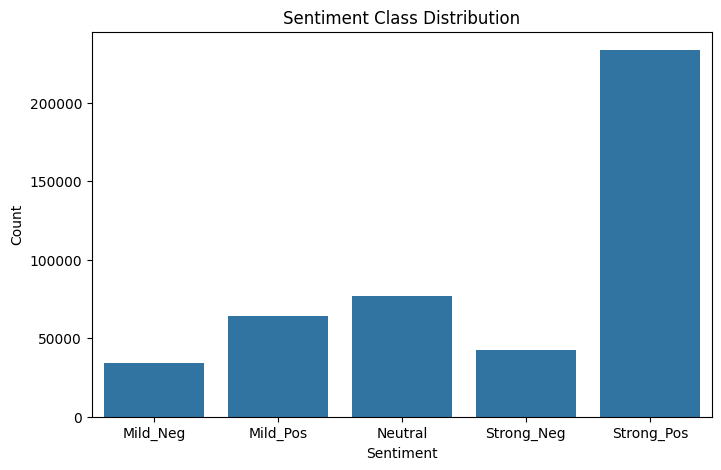

In [9]:
# Check class distribution
plt.figure(figsize=(8, 5))
sns.barplot(data=df.groupby('Sentiment').count(), x='Sentiment', y='Tweet')
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

### Mapping Sentiment to 3 Classes

In [10]:
# Mapping Sentiment to 3 Classes
def map_sentiment(sentiment):
    if sentiment in ['Mild_Pos', 'Strong_Pos']:
        return "Positive"
    elif sentiment in ['Mild_Neg', 'Strong_Neg']:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Sentiment"].apply(map_sentiment)
print("Unique Sentiments After Mapping:", df["Sentiment"].unique())

Unique Sentiments After Mapping: ['Positive' 'Neutral' 'Negative']


In [11]:
# Handle contractions (e.g., "won't" -> "will not")
def expand_contractions(text):
    contractions = {
        "won't": "will not",
        "can't": "cannot",
        "n't": " not",
        "'re": " are",
        "'s": " is",
        "'d": " would",
        "'ll": " will",
        "'t": " not",
        "'ve": " have",
        "'m": " am"
    }
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)
    return text

In [12]:
#Slang Dictionary
slang_dict = {
        "u": "you",
        "r": "are",
        "ur": "your",
        "idk": "I do not know",
        "btw": "by the way",
        "omg": "oh my god",
        "brb": "be right back",
        "bff": "best friend forever",
        "smh": "shaking my head",
        "tbh": "to be honest",
        "lmao": "laughing my ass off",
        "lol": "laughing out loud",
        "wtf": "what the heck",
        "rofl": "rolling on the floor laughing",
        "omw": "on my way",
        "fyi": "for your information",
        "nvm": "never mind",
        "tbt": "throwback Thursday",
        "imo": "in my opinion",
        "irl": "in real life",
        "fomo": "fear of missing out",
        "ftw": "for the win",
        "ttyl": "talk to you later",
        "wyd": "what are you doing",
        "wym": "what do you mean",
        "tldr": "too long; didn't read"
}

In [13]:
def preprocess_text(text):
    if not isinstance(text, str):  # Ensure text is a string
        text = str(text)
    text = text.lower()
    text = emoji.demojize(text)  # Convert emojis to text representation
    text = re.sub(r'#[A-Za-z0-9_]+', 'hashtag_', text)  # Replace hashtags
    text = re.sub(r'@[A-Za-z0-9_]+', 'mention_', text)  # Replace mentions
    text = re.sub(r'https?://\S+', 'url_', text)  # Replace URLs
    text = expand_contractions(text)
    text = ' '.join([slang_dict[word] if word in slang_dict else word for word in text.split()])  # Handle slang
    text = ' '.join([lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words])
    return text

In [14]:
# Apply preprocessing with tqdm progress bar
tqdm.pandas(desc="Cleaning Text Data")
df["Tweet"] = df["Tweet"].progress_apply(preprocess_text)

Cleaning Text Data: 100%|████████████████████████████████████████████████████████| 451332/451332 [02:48<00:00, 2675.20it/s]


In [15]:
# Save cleaned dataset
df.to_csv("E:/Dataset From NLP/Sentiment_Data/Cleaned_Sentiment_Data.csv", index=False)